In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 


In [2]:
#1. Loading dataset
df = df=pd.read_csv(r"C:\Users\fariq\Downloads\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
#2 display the first 10 entries
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [4]:
# These are the rown and columns of the dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (200, 5)


In [5]:
# These are the features of the dataset 
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
#checking for null values, Here there are no null values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# This provide the descriptive statistics for all numerical values
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


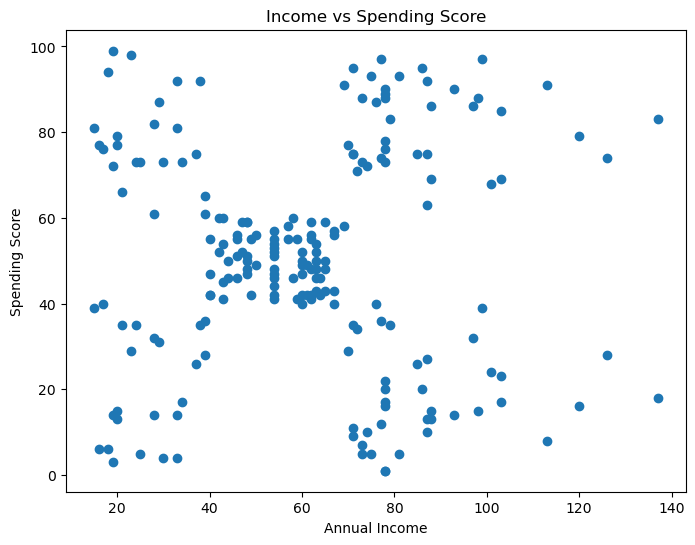

In [8]:
#Scatter PLot: Annual income vs spending score
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")

plt.show()

# Observations:

Here we can observe that customers are grouped into distinct regions rather than being spread uniformly.

1. High Income – High Spending Customers
Located in the upper-right region.
These are premium customers and contribute significantly to business revenue.
2. High Income – Low Spending Customers
Located in the lower-right region.
They have strong purchasing power but spend less than expected.
3. Low Income – High Spending Customers
Located in the upper-left region.
Despite lower income, they spend frequently and may be loyal customers.
4. Low Income – Low Spending Customers
Located in the lower-left region.
These customers spend less and are generally budget-conscious.
5. Average Customers
Found near the center of the graph.
They have moderate income and moderate spending habits.
Conclusion

The scatter plot suggests the presence of multiple customer groups (clusters) based on income and spending behavior. This indicates that K-Means Clustering can effectively segment the customers into meaningful categories for targeted marketing and business decision-making.

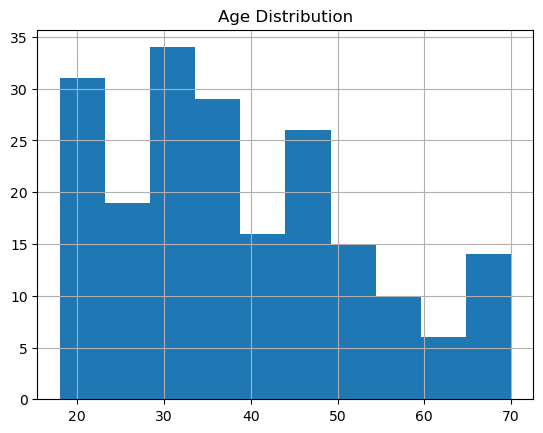

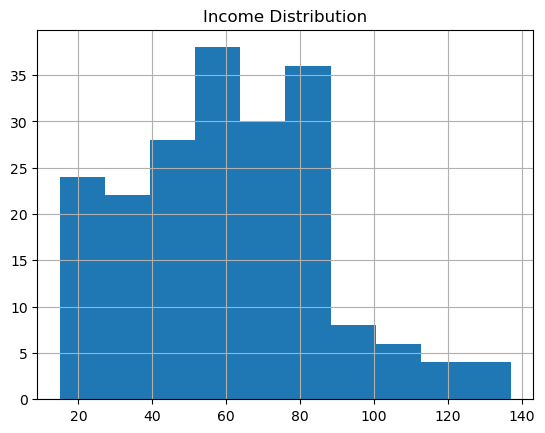

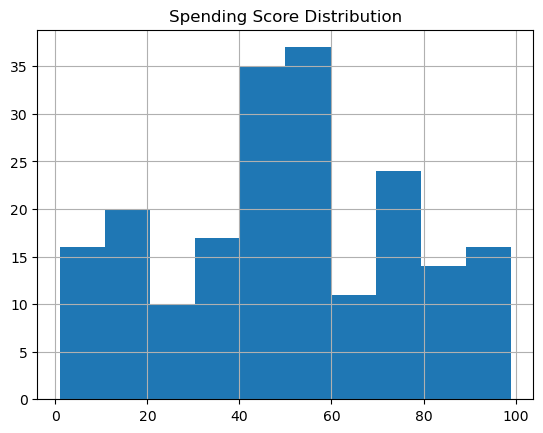

In [9]:
# histogram for age, annual income and spending score 
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

df['Annual Income (k$)'].hist()
plt.title("Income Distribution")
plt.show()

df['Spending Score (1-100)'].hist()
plt.title("Spending Score Distribution")
plt.show()

# In the above given graph

1. Age Distribution

Observation:
Most customers are between 20 and 40 years old.
The number of customers decreases as age increases beyond 40.
Very few customers are above 60 years.

Interpretation:
The mall mainly attracts young and middle-aged customers.
Marketing campaigns should focus on the preferences of customers in the 20–40 age group.

2. Annual Income Distribution

Observation:

Customer incomes are spread across different income levels.
Most customers fall into the middle-income range.
Very low-income and very high-income customers are fewer in number.

Interpretation:
The mall serves a broad customer base but is dominated by middle-income shoppers.
Businesses can offer products at different price ranges to cater to various income groups.

3. Spending Score Distribution

Observation:
Spending scores are distributed across the full range from 1 to 100.
Customers show different spending behaviors, from very low to very high spending.
No single spending level dominates the dataset.

Interpretation:
Customers have diverse purchasing habits.
This variation makes the dataset suitable for customer segmentation using K-Means clustering.
Businesses can identify high spenders, moderate spenders, and low spenders for targeted marketing.

# Conclusion
The histograms show that:

Most customers are young to middle-aged.
Most belong to the middle-income group.
Spending behavior varies significantly among customers.

These differences indicate that customers can be divided into meaningful groups, making K-Means clustering an effective technique for customer segmentation.

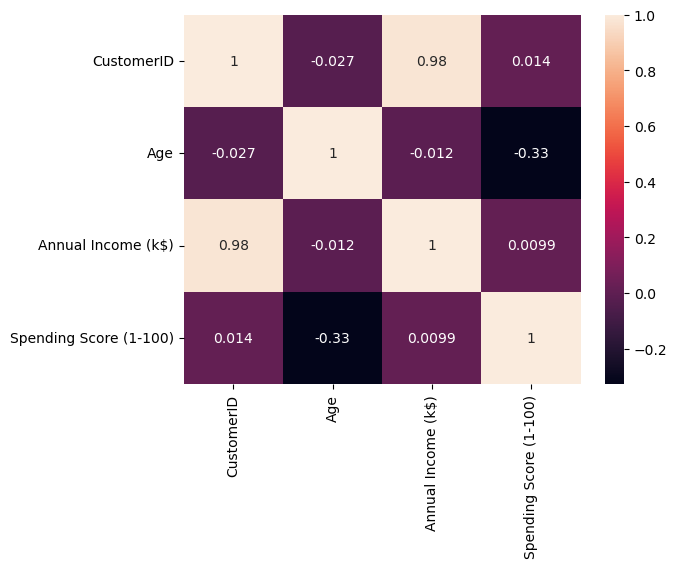

In [10]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

# The numerical features in the Mall Customers dataset are:

Age
Annual Income (k$)
Spending Score (1–100)

Analysis:

1. Age vs Spending Score:
  Shows a negative correlation.
  As age increases, the spending score generally tends to decrease.
  Younger customers tend to spend more compared to older customers.
2. Age vs Annual Income: 
   Shows a weak correlation.
   Age has little effect on a customer's annual income in this dataset.
   Both young and older customers are present across different income levels.
3. Annual Income vs Spending Score: 
  Shows a very weak or near-zero correlation.
  Higher income does not necessarily mean higher spending.
  Some high-income customers spend very little, while some lower-income customers spend a lot.

# Conclusion
  Age and Spending Score have the strongest relationship (negative correlation).
  Annual Income and Spending Score have a weak relationship, which suggests that spending behavior is not       determined solely by income.
  The weak correlations indicate that customers have diverse behaviors, making clustering useful for            discovering hidden customer segments.

In [11]:
# selecting features for clustering
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


# Why annual income and spending score are selected as features for clustering

These two features are selected because they provide the most useful information about customer purchasing behavior.

Annual Income (k$) represents the customer's earning capacity and purchasing power.
Spending Score (1–100) represents how much a customer tends to spend at the mall.

By combining these features, customers can be grouped into meaningful segments such as:

1. High Income – High Spending
2. High Income – Low Spending
3. Low Income – High Spending
4. Low Income – Low Spending

These segments help businesses understand customer behavior, design targeted marketing campaigns, improve customer satisfaction, and increase profits.

In [12]:
# applying the elbow method for k values ranging from 1 to 10
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

print(wcss)

C:\Users\fariq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fariq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fariq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\fariq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[269981.28, 181363.59595959593, 106348.37306211118, 73679.78903948836, 44448.45544793371, 37233.81451071001, 30241.343617936593, 25036.41760403398, 21916.794789843727, 20072.070939404006]


# Elbow Method 
The Elbow Method is a technique used to determine the optimal number of clusters (K) in K-Means Clustering.

It works by calculating the WCSS (Within-Cluster Sum of Squares) for different values of K.

WCSS measures how closely the data points are grouped around their cluster centroid.
As K increases, WCSS decreases because clusters become smaller and more compact.
The optimal K is chosen at the point where the decrease in WCSS starts slowing down significantly.
This point looks like an "elbow" in the graph, hence the name Elbow Method.

The Elbow Method was applied by training K-Means models for K values ranging from 1 to 10 and calculating the corresponding WCSS values. The WCSS values decrease as K increases because the clusters become more compact. These values are then used to plot the Elbow Curve to determine the optimal number of clusters.



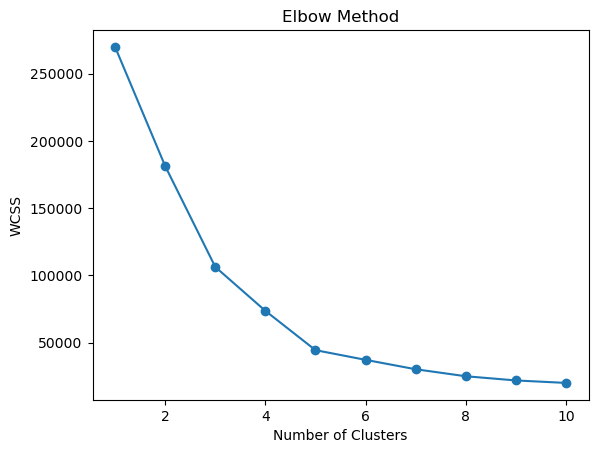

In [13]:
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# Observation:
After plotting the Elbow Curve using the WCSS values obtained for K = 1 to 10, a clear bend (elbow) is observed at K = 5.

This indicates that 5 clusters provide the best balance between cluster compactness and model simplicity. Beyond K = 5, the decrease in WCSS becomes much smaller, meaning that adding more clusters does not significantly improve the clustering results.

Conclusion:

Optimal Value of K = 5

This value is chosen because it represents the point where the Elbow Curve starts to flatten, indicating that further increases in K yield diminishing returns in reducing WCSS. Therefore, K = 5 is the most suitable number of clusters for customer segmentation in this dataset.

In [14]:
# Apply K-means
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

C:\Users\fariq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=5, n_init=10, random_state=42)

In [15]:
# assigning cluster labels
df['Cluster'] = kmeans.predict(X)

print(df['Cluster'])

0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32


In [16]:
#Displaying the first 10 records along with their cluster labels.
print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


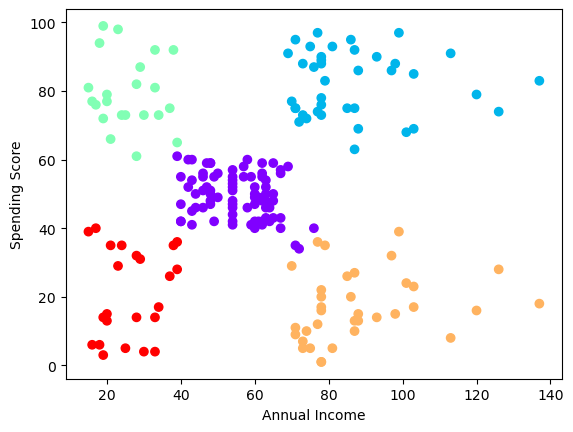

In [17]:
# Plotting the clustered customers using different colors for each cluster
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

# Observation 
The above given clustered scatter plot shows five distinct customer groups represented by different colors. Customers within the same cluster exhibit similar income and spending patterns, indicating that K-Means clustering effectively segments customers based on their purchasing behavior.

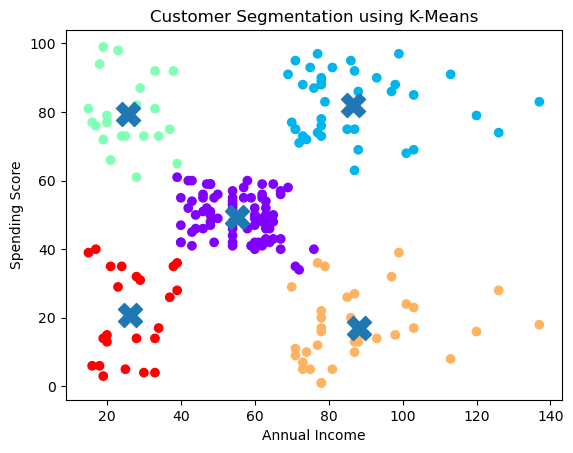

In [18]:
# Marking the cluster centroids on the scatter plot
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()

# Observation
The above given scatter plot displays cluster centroids as large 'X' markers at the center of each cluster. These centroids represent the average income and spending score of customers within a cluster. The centroids are clearly separated, indicating that K-Means clustering has successfully identified distinct customer segments.


In [19]:
# Interpreting the resulting customer groups.
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        'Annual Income',
        'Spending Score'
    ]
)

print(centers)

   Annual Income  Spending Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043


In [20]:
#. Identify the cluster containing:
#• High Income – High Spending customers
#• High Income – Low Spending customers
#• Low Income – High Spending customers
#• Low Income – Low Spending customers

centers = pd.DataFrame(kmeans.cluster_centers_, columns=['Income', 'Spending'])


mean_income = X.iloc[:, 0].mean()
mean_spending = X.iloc[:, 1].mean()


for i in range(len(centers)):
    print(f"\nCluster {i}:")
    
    income_val = centers.loc[i, 'Income']
    spending_val = centers.loc[i, 'Spending']
    
   
    if 40 <= income_val <= 70 and 40 <= spending_val <= 60:
        print("Standard / Average Consumers")
    else:
        if income_val > mean_income:
            if spending_val > mean_spending:
                print("High Income – High Spending customers")
            else:
                print("High Income – Low Spending customers")
        else:
            if spending_val > mean_spending:
                print("Low Income – High Spending customers")
            else:
                print("Low Income – Low Spending customers")


Cluster 0:
Standard / Average Consumers

Cluster 1:
High Income – High Spending customers

Cluster 2:
Low Income – High Spending customers

Cluster 3:
High Income – Low Spending customers

Cluster 4:
Low Income – Low Spending customers


# Observation

The customer segmentation process successfully identified distinct customer groups based on Annual Income and Spending Score. The clusters reveal that customers exhibit different spending behaviors despite having similar income levels. High Income–High Spending customers form the most profitable segment, while High Income–Low Spending customers represent a potential growth opportunity. Similarly, Low Income–High Spending customers demonstrate strong purchasing interest despite lower income levels. These observations help businesses understand customer behavior and design targeted marketing strategies for each segment.






# Which customer segment is most valuable to a business?
The High Income – High Spending customer segment is the most valuable to a business.
 
These customers have strong purchasing power and spend frequently.
They contribute the highest revenue and profit to the business.
They are more likely to purchase premium and luxury products.
They have a higher customer lifetime value compared to other segments.
Retaining these customers can significantly increase business growth and profitability.
Observation

High Income – High Spending customers represent the most profitable segment because they combine high purchasing power with high spending behavior. Businesses should focus on retaining these customers through personalized services, loyalty programs and exclusive offers.


# Which customer segment offers the greatest growth opportunity? 
The High Income – Low Spending customer segment offers the greatest growth opportunity.


These customers have high purchasing power but currently spend less.
Since they already have the financial ability to buy more products, businesses can encourage additional spending through targeted marketing strategies.
Personalized recommendations, loyalty programs, special discounts, and premium product promotions can help convert them into High Income – High Spending customers.
Increasing the spending of this segment can significantly boost revenue without acquiring new customers.


High Income – Low Spending customers represent untapped potential for the business. They have the ability to spend more but are currently underutilizing their purchasing power. Effective marketing efforts can transform them into highly profitable customers.

# Suggest one marketing strategy for each customer cluster
High Income – High Spending Customers:
Offer VIP memberships, exclusive rewards, and premium services to retain these valuable customers.

High Income – Low Spending Customers:
Provide personalized discounts and special offers to encourage more purchases.

Low Income – High Spending Customers:
Introduce loyalty programs and reward points to maintain customer engagement.

Low Income – Low Spending Customers:
Promote budget-friendly products and seasonal discounts to increase sales.

Average Income – Average Spending Customers:
Use cross-selling and upselling techniques to increase their spending.


# Summarizing the insights obtained from customer segmentation using K-Means Clustering
Customer segmentation using K-Means Clustering successfully grouped customers into different clusters based on their Annual Income and Spending Score. The analysis revealed distinct customer segments such as High Income–High Spending, High Income–Low Spending, Low Income–High Spending, Low Income–Low Spending, and Average Customers.

These segments help businesses understand customer behavior, identify their most valuable customers, recognize potential growth opportunities, and develop targeted marketing strategies. The clustering results provide valuable insights that can improve customer satisfaction, increase sales, and support better business decision-making.

#  How businesses can use these clusters for targeted marketing and decision-making.
Businesses can use customer clusters to understand the needs and preferences of different customer groups. By analyzing these segments, companies can create personalized marketing campaigns, offer relevant products, and improve customer satisfaction.

For example:

1. High Income – High Spending customers can be targeted with premium products and VIP programs.
2. High Income – Low Spending customers can be encouraged to spend more through special offers and personalized recommendations.
3. Low Income – High Spending customers can be retained using loyalty rewards and discounts.
4. Low Income – Low Spending customers can be attracted with budget-friendly products and promotional offers.

Customer segmentation also helps businesses make better decisions regarding product development, pricing strategies, inventory management, and resource allocation. As a result, companies can improve customer retention, increase sales, and maximize profits.

# The advantages and limitations of K-Means Clustering in real-world customer segmentation

Advantages of K-Means Clustering:

1. Simple and Easy to Implement
K-Means is easy to understand and apply.
2. Fast and Efficient
It works quickly even with large datasets.
3. Identifies Customer Groups
Helps businesses segment customers based on similar characteristics.
4. Improves Marketing Strategies
Enables targeted marketing and personalized customer experiences.
5. Easy to Visualize
The resulting clusters can be represented graphically for better analysis.


Limitations of K-Means Clustering:

1. Requires Predefined Number of Clusters (K)
The value of K must be chosen before running the algorithm.
2. Sensitive to Outliers
Extreme values can affect the position of centroids and reduce accuracy.
3. May Produce Different Results
Different initial centroid selections can lead to different cluster formations.
4. Assumes Spherical Clusters
K-Means works best when clusters are roughly circular and evenly sized.
Not Suitable for All Datasets
It may not perform well when clusters have complex shapes or overlapping patterns.